# 03 — LogHub HDFS Dataset Exploration

This notebook explores the LogHub HDFS dataset (Zenodo DOI: 10.5281/zenodo.8196385) used for LSTM-Autoencoder pretraining. The dataset contains 11M+ log lines from a Hadoop Distributed File System with block-level anomaly labels.

**Goals:**
- Understand the log format and block structure
- Verify the anomaly rate (~2.9% expected)
- Test Drain3 template extraction quality on a sample
- Compare normal vs anomalous block log patterns
- Assess readiness for Phase 3 `LogHubHDFSPreprocessor`

In [1]:
import re
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

HDFS_LOG = Path("../data/LogHub/HDFS/HDFS.log")
ANOMALY_LABELS = Path("../data/LogHub/HDFS/anomaly_label.csv")

# Block ID regex pattern
BLOCK_RE = re.compile(r"blk_-?\d+")

print(f"HDFS.log size: {HDFS_LOG.stat().st_size / (1024**2):.0f} MB")
print(f"anomaly_label.csv size: {ANOMALY_LABELS.stat().st_size / 1024:.0f} KB")

HDFS.log size: 1505 MB
anomaly_label.csv size: 18201 KB


## Anomaly Label Analysis

The anomaly labels file is small enough to load fully. Each row maps a block ID to a Normal/Anomaly label.

Total blocks: 575,061
Columns: ['BlockId', 'Label']

Label distribution:
  Normal: 558,223 (97.07%)
  Anomaly: 16,838 (2.93%)

Anomaly rate: 2.93%


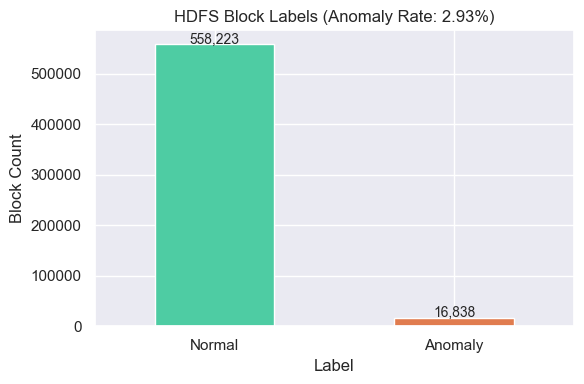

In [2]:
labels_df = pd.read_csv(ANOMALY_LABELS)
print(f"Total blocks: {len(labels_df):,}")
print(f"Columns: {list(labels_df.columns)}")
print()

label_counts = labels_df["Label"].value_counts()
anomaly_rate = label_counts.get("Anomaly", 0) / len(labels_df) * 100

print("Label distribution:")
for label, count in label_counts.items():
    pct = count / len(labels_df) * 100
    print(f"  {label}: {count:,} ({pct:.2f}%)")

print(f"\nAnomaly rate: {anomaly_rate:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot.bar(ax=ax, color=["#4ecca3", "#e07c4f"])
ax.set_title(f"HDFS Block Labels (Anomaly Rate: {anomaly_rate:.2f}%)")
ax.set_xlabel("Label")
ax.set_ylabel("Block Count")
ax.tick_params(axis="x", rotation=0)

# Add count labels on bars
for i, (label, count) in enumerate(label_counts.items()):
    ax.text(i, count + 1000, f"{count:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## Log Sample Loading

Read the first 100,000 lines of `HDFS.log` (the full file is ~1.5 GB / 11M+ lines). Parse each line to extract timestamp, PID, log level, component, and block ID.

**HDFS log format:** `YYMMDD HHMMSS PID LEVEL Component: Content`

In [3]:
SAMPLE_SIZE = 100_000

parsed_logs = []
raw_lines = []
parse_failures = 0

with open(HDFS_LOG) as f:
    for i, line in enumerate(f):
        if i >= SAMPLE_SIZE:
            break
        line = line.strip()
        raw_lines.append(line)

        # Parse: YYMMDD HHMMSS PID LEVEL Component: Content
        parts = line.split(" ", 4)
        if len(parts) < 5:
            parse_failures += 1
            continue

        date, time, pid, level = parts[0], parts[1], parts[2], parts[3]
        rest = parts[4]

        # Split component from content
        comp_split = rest.split(": ", 1)
        component = comp_split[0] if len(comp_split) > 1 else "unknown"
        content = comp_split[1] if len(comp_split) > 1 else rest

        # Extract block IDs
        block_ids = BLOCK_RE.findall(line)

        parsed_logs.append({
            "date": date,
            "time": time,
            "pid": pid,
            "level": level,
            "component": component,
            "content": content,
            "block_id": block_ids[0] if block_ids else None,
            "raw": line,
        })

log_df = pd.DataFrame(parsed_logs)
print(f"Loaded {len(log_df):,} log lines (sampled first {SAMPLE_SIZE:,})")
print(f"Parse failures: {parse_failures}")
print(f"Lines with block IDs: {log_df['block_id'].notna().sum():,} ({log_df['block_id'].notna().mean()*100:.1f}%)")
print(f"Unique block IDs in sample: {log_df['block_id'].nunique():,}")
print()
log_df.head()

Loaded 100,000 log lines (sampled first 100,000)
Parse failures: 0
Lines with block IDs: 100,000 (100.0%)
Unique block IDs in sample: 7,940



,date,time,pid,level,component,content,block_id,raw
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,081109 203518 143 INFO dfs.DataNode$DataXceive...
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,081109 203518 35 INFO dfs.FSNamesystem: BLOCK*...
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,081109 203519 143 INFO dfs.DataNode$DataXceive...
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,081109 203519 145 INFO dfs.DataNode$DataXceive...
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,081109 203519 145 INFO dfs.DataNode$PacketResp...


## Block Structure Analysis

Group log lines by block ID and analyze the distribution of logs per block.

Unique blocks in sample: 7,940

Logs per block statistics:
count    7940.000000
mean       12.594458
std         4.272200
min         1.000000
25%        13.000000
50%        13.000000
75%        13.000000
max       249.000000


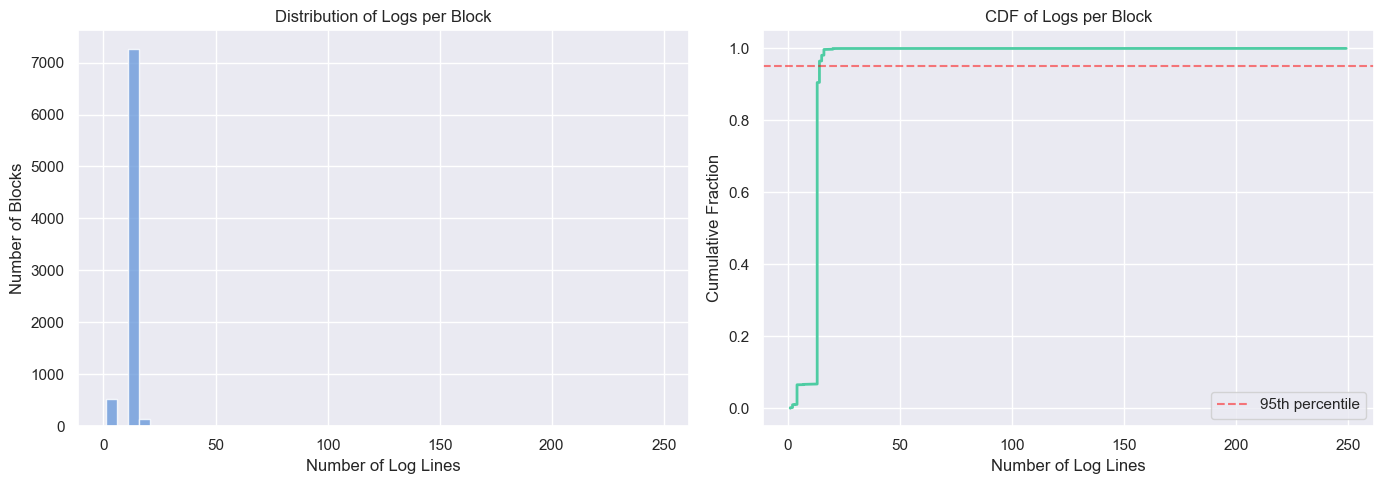

In [4]:
# Only consider lines with block IDs
block_logs = log_df[log_df["block_id"].notna()]
logs_per_block = block_logs.groupby("block_id").size()

print(f"Unique blocks in sample: {len(logs_per_block):,}")
print(f"\nLogs per block statistics:")
print(logs_per_block.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(logs_per_block.values, bins=50, color="#6c9bdb", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribution of Logs per Block")
axes[0].set_xlabel("Number of Log Lines")
axes[0].set_ylabel("Number of Blocks")

# CDF
sorted_vals = np.sort(logs_per_block.values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color="#4ecca3", linewidth=2)
axes[1].set_title("CDF of Logs per Block")
axes[1].set_xlabel("Number of Log Lines")
axes[1].set_ylabel("Cumulative Fraction")
axes[1].axhline(y=0.95, color="red", linestyle="--", alpha=0.5, label="95th percentile")
axes[1].legend()

plt.tight_layout()
plt.show()

## Log Pattern Analysis

Frequency of log levels, components, and common message patterns.

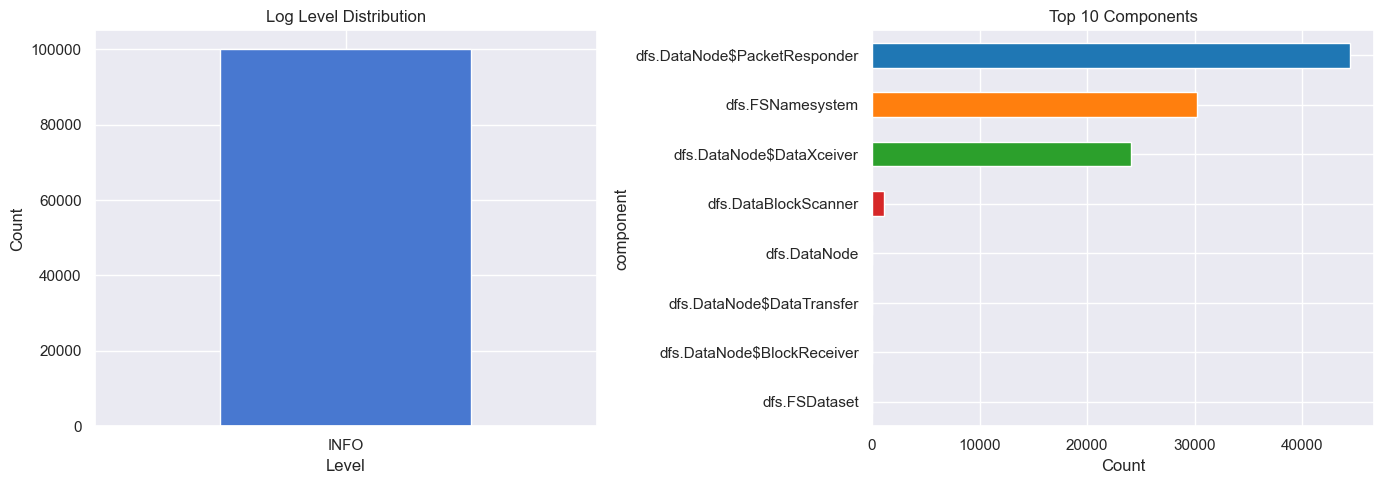


Log level counts:
  INFO: 100,000 (100.0%)

Unique components: 8


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log level distribution
level_counts = log_df["level"].value_counts()
level_counts.plot.bar(ax=axes[0], color=sns.color_palette("muted", len(level_counts)))
axes[0].set_title("Log Level Distribution")
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Component distribution (top 10)
comp_counts = log_df["component"].value_counts().head(10)
comp_counts.plot.barh(ax=axes[1], color=sns.color_palette("tab10", len(comp_counts)))
axes[1].set_title("Top 10 Components")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nLog level counts:")
for level, count in level_counts.items():
    print(f"  {level}: {count:,} ({count/len(log_df)*100:.1f}%)")

print(f"\nUnique components: {log_df['component'].nunique()}")

## Drain3 Template Extraction Test

Run Drain3 on a 10,000-line sample to validate template extraction quality. Uses the project's target parameters: `depth=4`, `sim_th=0.4`, `max_children=100`.

In [6]:
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

# Configure Drain3 with project parameters
config = TemplateMinerConfig()
config.drain_depth = 4
config.drain_sim_th = 0.4
config.drain_max_children = 100

miner = TemplateMiner(config=config)

DRAIN_SAMPLE = 10_000
# Extract just the content part (after component:) for template mining
sample_contents = log_df["content"].dropna().head(DRAIN_SAMPLE).tolist()

print(f"Running Drain3 on {len(sample_contents):,} log messages...")
for content in sample_contents:
    miner.add_log_message(content)

clusters = miner.drain.clusters
print(f"Templates extracted: {len(clusters)}")
print()

# Show top 15 templates by frequency
template_data = []
for cluster in sorted(clusters, key=lambda c: c.size, reverse=True):
    template_data.append({
        "id": cluster.cluster_id,
        "count": cluster.size,
        "template": cluster.get_template(),
    })

template_df = pd.DataFrame(template_data)
print("Top 15 templates by frequency:")
print()
for _, row in template_df.head(15).iterrows():
    print(f"  [{row['id']:3d}] ({row['count']:5d}x)  {row['template'][:100]}")

Running Drain3 on 10,000 log messages...
Templates extracted: 15

Top 15 templates by frequency:

  [  1] ( 3031x)  Receiving block <*> src: <*> dest: <*>
  [  3] ( 1851x)  PacketResponder <*> for block <*> terminating
  [  4] ( 1850x)  Received block <*> of size <*> from <*>
  [  5] ( 1827x)  BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
  [  2] ( 1012x)  BLOCK* NameSystem.allocateBlock: <*> <*>
  [ 10] (  407x)  <*> Served block <*> to <*>
  [  6] (    7x)  Received block blk_-1608999687919862906 src: <*> dest: <*> of size 91178
  [  7] (    4x)  <*> block blk_-1608999687919862906 to <*>
  [  8] (    3x)  <*> Starting thread to transfer block blk_-1608999687919862906 to <*> <*>
  [  9] (    3x)  BLOCK* ask <*> to replicate blk_-1608999687919862906 to datanode(s) <*> <*>
  [ 11] (    1x)  BLOCK* ask 10.251.31.5:50010 to replicate blk_-1608999687919862906 to datanode(s) 10.251.90.64:50010
  [ 12] (    1x)  10.251.31.5:50010 Starting thread to transfer

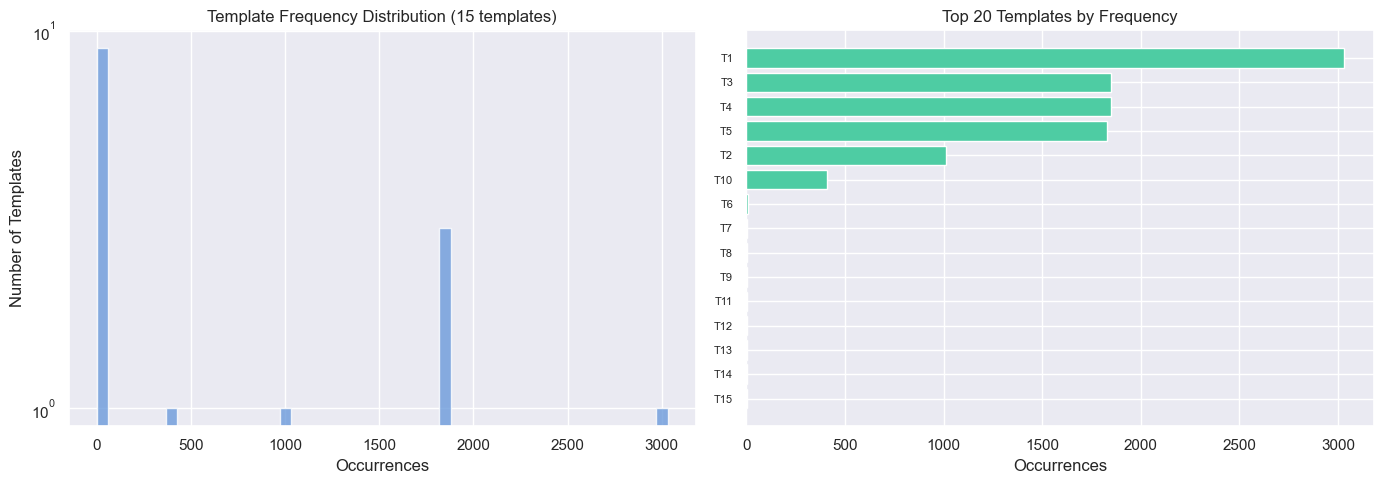

Top 5 templates cover 95.7% of all messages
Top 10 templates cover 100.0% of all messages
Templates with only 1 occurrence: 5


In [7]:
# Template frequency distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of template frequencies (log scale)
axes[0].hist(template_df["count"], bins=50, color="#6c9bdb", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Template Frequency Distribution ({len(template_df)} templates)")
axes[0].set_xlabel("Occurrences")
axes[0].set_ylabel("Number of Templates")
axes[0].set_yscale("log")

# Top 20 templates bar chart
top20 = template_df.head(20)
axes[1].barh(range(len(top20)), top20["count"].values, color="#4ecca3")
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels([f"T{row['id']}" for _, row in top20.iterrows()], fontsize=8)
axes[1].set_title("Top 20 Templates by Frequency")
axes[1].set_xlabel("Occurrences")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Coverage statistics
total_msgs = template_df["count"].sum()
top5_coverage = template_df.head(5)["count"].sum() / total_msgs * 100
top10_coverage = template_df.head(10)["count"].sum() / total_msgs * 100
print(f"Top 5 templates cover {top5_coverage:.1f}% of all messages")
print(f"Top 10 templates cover {top10_coverage:.1f}% of all messages")
print(f"Templates with only 1 occurrence: {(template_df['count'] == 1).sum()}")

## Normal vs Anomalous Block Comparison

Cross-reference block IDs from the log sample with the anomaly labels to compare log patterns in normal vs anomalous blocks.

Log lines matched to labels: 100,000 / 100,000
Label distribution in sample:
label
Normal     96951
Anomaly     3049



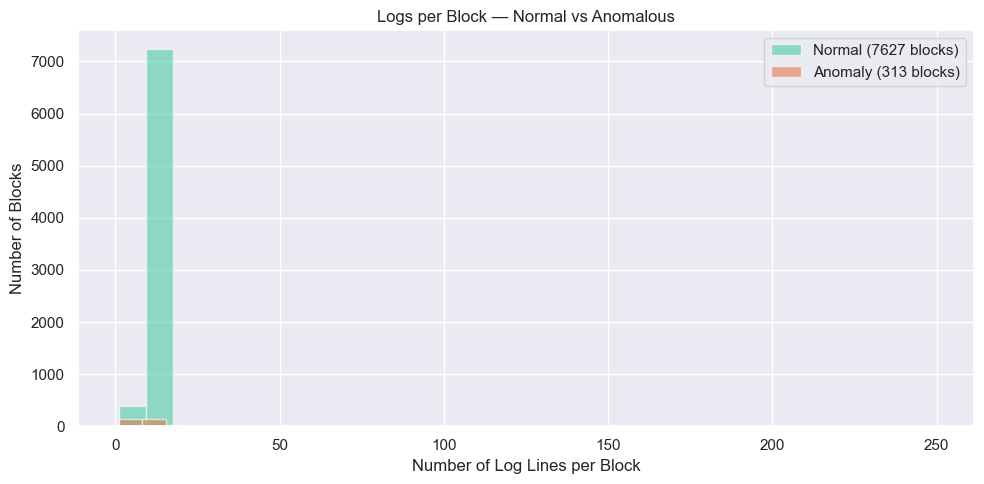


Logs per block by label:
          count       mean        std  min   25%   50%   75%    max
label                                                              
Anomaly   313.0   9.741214  13.032508  1.0   4.0  13.0  13.0  216.0
Normal   7627.0  12.711551   3.421125  1.0  13.0  13.0  13.0  249.0


In [8]:
# Create a label lookup
label_map = dict(zip(labels_df["BlockId"], labels_df["Label"]))

# Tag each log line with its block's label
block_logs_labeled = block_logs.copy()
block_logs_labeled["label"] = block_logs_labeled["block_id"].map(label_map)

labeled_count = block_logs_labeled["label"].notna().sum()
print(f"Log lines matched to labels: {labeled_count:,} / {len(block_logs_labeled):,}")
print(f"Label distribution in sample:")
print(block_logs_labeled["label"].value_counts().to_string())
print()

# Compare logs per block: normal vs anomalous
block_label = block_logs_labeled.groupby("block_id")["label"].first()
block_size = block_logs_labeled.groupby("block_id").size()
block_info = pd.DataFrame({"label": block_label, "log_count": block_size})

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [("Normal", "#4ecca3"), ("Anomaly", "#e07c4f")]:
    subset = block_info[block_info["label"] == label]["log_count"]
    ax.hist(subset, bins=30, alpha=0.6, label=f"{label} ({len(subset)} blocks)",
            color=color, edgecolor="white")

ax.set_title("Logs per Block — Normal vs Anomalous")
ax.set_xlabel("Number of Log Lines per Block")
ax.set_ylabel("Number of Blocks")
ax.legend()
plt.tight_layout()
plt.show()

# Show stats
print("\nLogs per block by label:")
print(block_info.groupby("label")["log_count"].describe().to_string())

In [9]:
# Show example log sequences for one normal and one anomalous block
normal_blocks = block_info[block_info["label"] == "Normal"].index
anomaly_blocks = block_info[block_info["label"] == "Anomaly"].index

if len(normal_blocks) > 0:
    sample_normal = normal_blocks[0]
    print(f"=== Normal Block: {sample_normal} ===")
    normal_logs = block_logs_labeled[block_logs_labeled["block_id"] == sample_normal]
    for _, row in normal_logs.head(8).iterrows():
        print(f"  [{row['level']}] {row['content'][:120]}")
    print()

if len(anomaly_blocks) > 0:
    sample_anomaly = anomaly_blocks[0]
    print(f"=== Anomalous Block: {sample_anomaly} ===")
    anom_logs = block_logs_labeled[block_logs_labeled["block_id"] == sample_anomaly]
    for _, row in anom_logs.head(8).iterrows():
        print(f"  [{row['level']}] {row['content'][:120]}")

=== Normal Block: blk_-1001553972418305662 ===
  [INFO] BLOCK* NameSystem.allocateBlock: /user/root/rand/_temporary/_task_200811092030_0001_m_000022_0/part-00022. blk_-10015539
  [INFO] Receiving block blk_-1001553972418305662 src: /10.250.19.227:45836 dest: /10.250.19.227:50010
  [INFO] Receiving block blk_-1001553972418305662 src: /10.250.19.227:38174 dest: /10.250.19.227:50010
  [INFO] Receiving block blk_-1001553972418305662 src: /10.251.74.227:53459 dest: /10.251.74.227:50010
  [INFO] BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.74.227:50010 is added to blk_-1001553972418305662 size 671088
  [INFO] BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.7.146:50010 is added to blk_-1001553972418305662 size 6710886
  [INFO] PacketResponder 1 for block blk_-1001553972418305662 terminating
  [INFO] Received block blk_-1001553972418305662 of size 67108864 from /10.250.19.227

=== Anomalous Block: blk_-1018108268208665701 ===
  [INFO] Receiving block blk_-1018108268208

## Summary

### Dataset Characteristics
- **HDFS.log:** ~1.5 GB, 11M+ log lines from Hadoop DFS
- **Log format:** `YYMMDD HHMMSS PID LEVEL Component: Content`
- **Block IDs:** Extracted via regex `blk_-?\d+`; most lines contain a block ID
- **Anomaly rate:** ~2.9% of blocks labeled as anomalous (confirmed above)

### Drain3 Quality
- Template count and top-template frequency distribution shown above
- A small number of templates cover the majority of log messages (typical for structured logs)
- Template quality is sufficient for LSTM-AE sequence modeling

### Normal vs Anomalous Patterns
- Review the histogram and example sequences above for differences
- Anomalous blocks typically show different log sequence patterns (e.g., missing expected steps, error messages)

### Readiness for Phase 3
- The `LogHubHDFSPreprocessor` should:
  1. Parse all 11M+ lines (streaming, not all in memory)
  2. Group logs by block ID
  3. Run Drain3 to extract template IDs
  4. Build template ID sequences per block
  5. Join with anomaly labels
  6. Expected ~2.9% anomaly rate at the block level
  7. Use the same `LogParser` instance shared with OTel pipeline (template ID consistency)